In [ ]:
import numpy as np                     # Numerical programming package
import matplotlib.pyplot as plt        # Plotting library

In [ ]:
### Helper ###
# If you have some doubts about the notation to iterate
# over a numpy vector, you are invited to run this block of code

test = np.array([0,1,2,3,4,5,6,7,8])
print("test      : ", test)
print("test[0:]  : ", test[0:])
print("test[1:]  : ",test[1:])
print("test[2:]  : ",test[2:])
print("test[1:3] : ",test[1:3])
print("test[:-1] : ",test[:-1])
print("test[:-2] : ",test[:-2])
print("test[1:-1]: ",test[1:-1])
print("test[-2:] : ",test[-2:])
print("test[8]   : ",test[8])
print("test[-8]  : ",test[-8])
try:
    res = test[9]
except Exception as ex:
    print("test[9]   : ", ex)

try:
    res = test[-10]
except Exception as ex:
    print("test[-10] : ", ex)

test      :  [0 1 2 3 4 5 6 7 8]
test[0:]  :  [0 1 2 3 4 5 6 7 8]
test[1:]  :  [1 2 3 4 5 6 7 8]
test[2:]  :  [2 3 4 5 6 7 8]
test[1:3] :  [1 2]
test[:-1] :  [0 1 2 3 4 5 6 7]
test[:-2] :  [0 1 2 3 4 5 6]
test[1:-1]:  [1 2 3 4 5 6 7]
test[-2:] :  [7 8]
test[8]   :  8
test[-8]  :  1
test[9]   :  index 9 is out of bounds for axis 0 with size 9
test[-10] :  index -10 is out of bounds for axis 0 with size 9


### Exercise 1: use the Forward Time Centered Space scheme to solve the linear advection equation

Consider the following advection equation in 1D:

$\dfrac{\partial \rho}{\partial t} + v \dfrac{\partial \rho}{\partial x} = 0$

Given an initial condition at $t=0$, this equation can be solved analytically by using the characteristics method: $\rho(x,t) = \rho(x-vt, 0)$.

Implement the following finite-difference scheme (the [Forward Time Centered Space scheme](https://en.wikipedia.org/wiki/FTCS_scheme)) to solve the advection equation by completing the code inside the `advection_FTCS` function:

$\dfrac{\rho^{(n+1)}_j - \rho^{(n)}_j}{\Delta t} = - v \dfrac{\rho^{(n)}_{j+1} - \rho^{(n)}_{j-1}}{2 \Delta x} $

Run the code block `do_test_advection_FTCS` to see that this scheme does not work for advection equation.

#### Ideas if you finish early:

- copy the `do_test_advection_FTCS` function into another block, change the name and experiment with different settings, e.g. : a higher or a lower resolution (change `N = 400`), a different initial function (change `rho = (x < 1)*(x > -1)*1.0`), different timestep sizes (change `dts = [1e-3, 1e-4, 1e-5]`)...

In [ ]:
def advection_FTCS (rho, v,  dx, dt):
    """
    Computes one step of the FTCS scheme applied to the 1D avection equation:
    it receives rho at time n and it returns rho at time n+1.
    Periodic boundary conditions are applied using guard cells at rho[0] and rho[-1]

    Parameters
    ----------
    rho : array of floats
        N-components vector of the values of rho at time n
    v : float
        velocity to be used for the advection
    dx : float
        spatial resolution
    dt : array of floats
        temporal resolution
    Returns
    -------
    new_rho : array of floats
        rho computed at timestep n+1
    """

    new_rho = np.zeros(rho.shape[0])

    ### ADD YOUR CODE HERE ####
    new_rho[1:-1] = rho[1:-1] -dt/(2*dx)*(v*(rho[2:]-rho[:-2]))
    #
    # note: cells 0 and -1 are used as guard cells to
    # enforce boundary conditions, so don't touch them here!
    ### ADD YOUR CODE HERE ####

    # Periodic boundary conditions
    new_rho[-1] = new_rho[1]
    new_rho[0] = new_rho[-2]

    return new_rho

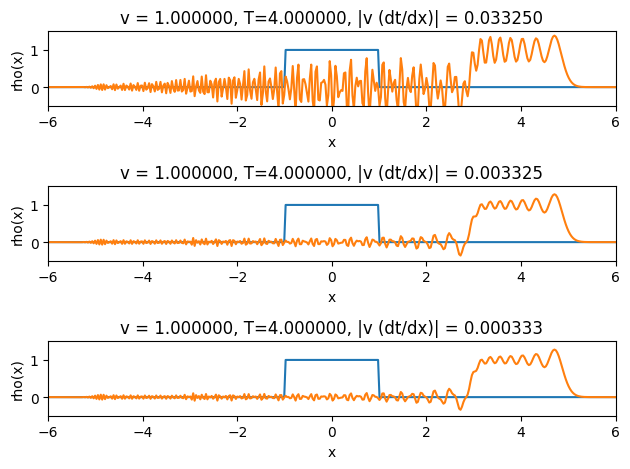

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_test_advection_FTCS():
    '''
    Performs a test of the advection_FTCS function
    '''
    N = 400

    x = np.linspace(-6.0, 6.0, N)
    dx = (x[-1]-x[0])/(N-1)
    rho = (x < 1)*(x > -1)*1.0

    fig, ax = plt.subplots(3)

    v = 1.0

    T = 4

    dts = [1e-3, 1e-4, 1e-5]

    for i, dt in enumerate(dts) :
        ax[i].plot(x,rho)
        nrho = np.copy(rho)
        for _ in range (int(T/dt)):
            nrho = advection_FTCS(nrho, v, dx, dt)
        ax[i].plot(x,nrho)
        ax[i].set_xlabel("x")
        ax[i].set_ylabel("rho(x)")
        ax[i].set_title("v = {:f}, T={:f}, |v (dt/dx)| = {:f}".format(v, T, np.abs(v*(dt/dx))))
        ax[i].set_xlim(-6,6)
        ax[i].set_ylim(-0.5,1.5)

    plt.tight_layout()

do_test_advection_FTCS()

### Exercise 2: use the upwind method to solve the linear advection equation

Consider the following advection equation in 1D:

$\dfrac{\partial \rho}{\partial t} + v \dfrac{\partial \rho}{\partial x} = 0$

Given an initial condition at $t=0$, this equation can be solved analytically by using the characteristics method: $\rho(x,t) = \rho(x-vt, 0)$.

Implement the following finite-difference scheme (the [Upwind scheme](https://en.wikipedia.org/wiki/Upwind_scheme)) to solve the advection equation by completing the code inside the `advection_upwind` function:

- $\dfrac{\rho^{(n+1)}_j - \rho^{(n)}_j}{\Delta t} = - v \dfrac{\rho^{(n)}_{j} - \rho^{(n)}_{j-1}}{\Delta x} $ for v >= 0
- $\dfrac{\rho^{(n+1)}_j - \rho^{(n)}_j}{\Delta t} = - v \dfrac{\rho^{(n)}_{j+1} - \rho^{(n)}_{j}}{\Delta x} $ for v < 0

Run the code block `do_test_advection_upwind`.

#### Ideas if you finish early:
- copy the `do_test_advection_upwind` function into another block, change the name and experiment with different settings, e.g. : a higher or a lower resolution (change `N = 400`), a different initial function (change `rho = (x < 1)*(x > -1)*1.0`), different timestep sizes (change `dts = [0.5*np.abs(dx/vp), 1.0*np.abs(dx/vp), 1.1*np.abs(dx/vp)]`)...

In [ ]:
def advection_upwind(rho, v,  dx, dt):
    """
    Computes one step of the upwind scheme applied to the 1D avection equation:
    it receives rho at time n and it returns rho at time n+1.
    Periodic boundary conditions are applied using guard cells at rho[0] and rho[-1]
    (only one guard cell is used, depending on the sign of v)

    Parameters
    ----------
    rho : array of floats
        N-components vector of the values of rho at time n
    v : float
        velocity to be used for the advection
    dx : float
        spatial resolution
    dt : array of floats
        temporal resolution
    Returns
    -------
    new_rho : array of floats
        rho computed at timestep n+1
    """

    new_rho = np.zeros(rho.shape[0])

    ### ADD YOUR CODE HERE ####
    if (v >= 0):
        new_rho[1:-1] = rho[1:-1] -dt/(dx)*(v*(rho[1:-1]-rho[:-2]))
    else:
        new_rho[1:-1] = rho[1:-1] -dt/(dx)*(v*(rho[2:]-rho[1:-1]))
    #
    # note: cells 0 or -1 are used as guard cells to
    # enforce boundary conditions (depending on the sign of v)!
    ### ADD YOUR CODE HERE ####

    # Periodic boundary conditions
    if (v >= 0):
        new_rho[0] = new_rho[-2]
    else:
        new_rho[-1] = new_rho[1]
    return new_rho

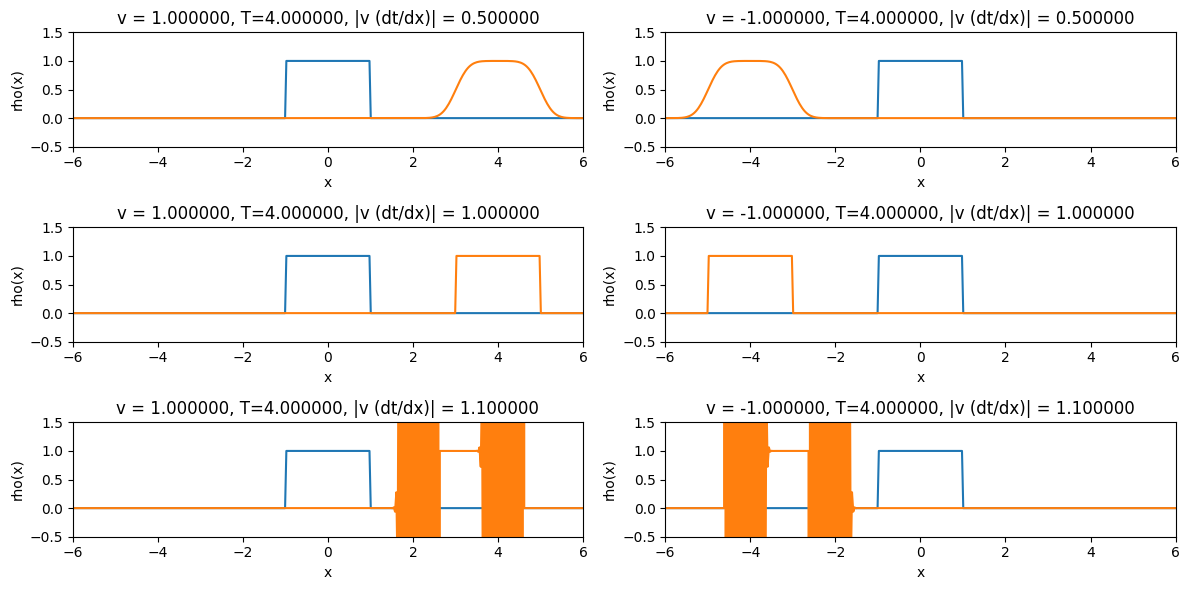

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_test_advection_upwind():
    '''
    Performs a test of the advection_upwind function
    '''
    N = 400

    x = np.linspace(-6.0, 6.0, N)
    dx = (x[-1]-x[0])/(N-1)
    rho = (x < 1)*(x > -1)*1.0

    fig, ax = plt.subplots(3,2, figsize=(12,6))

    vp = 1.0

    dts = [0.5*np.abs(dx/vp), 1.0*np.abs(dx/vp), 1.1*np.abs(dx/vp)]

    vs = [vp, -vp]

    T = 4

    for i, v in enumerate(vs) :
        for j, dt in enumerate(dts) :

            idx = i*len(dts) + j

            ax[j,i].plot(x,rho)
            nrho = np.copy(rho)
            for _ in range (int(T/dt)):
                nrho = advection_upwind(nrho, v, dx, dt)
            ax[j,i].plot(x,nrho)
            ax[j,i].set_xlabel("x")
            ax[j,i].set_ylabel("rho(x)")
            ax[j,i].set_title("v = {:f}, T={:f}, |v (dt/dx)| = {:f}".format(v, T, np.abs(v*(dt/dx))))
            ax[j,i].set_xlim(-6,6)
            ax[j,i].set_ylim(-0.5,1.5)

    plt.tight_layout()

do_test_advection_upwind()

### Exercise 3: use the Lax-Wendroff method to solve the linear advection equation

Consider the following advection equation in 1D:

$\dfrac{\partial \rho}{\partial t} + v \dfrac{\partial \rho}{\partial x} = 0$

Given an initial condition at $t=0$, this equation can be solved analytically by using the characteristics method: $\rho(x,t) = \rho(x-vt, 0)$.

Implement the following finite-difference scheme (the [Lax-Wendroff scheme](https://en.wikipedia.org/wiki/Lax%E2%80%93Wendroff_method)) to solve the advection equation by completing the code inside the `advection_lax_wendroff` function:

$\rho^{(n+1)}_j =  \rho^{(n)}_j - v \left({\dfrac{\Delta t}{\Delta x}}\right)\dfrac{\rho^{(n)}_{j+1} - \rho^{(n)}_{j-1}}{2} + \dfrac{v^2}{2} \left({\dfrac{\Delta t}{\Delta x}}\right)^2 \left({\rho^{(n)}_{j+1} - 2 \rho^{(n)}_{j} + \rho^{(n)}_{j-1}}\right)   $

Run the code block `do_test_advection_lax_wendroff` to test your solution.

#### Ideas if you finish early:
- copy the `do_test_advection_lax_wendroff` function into another block, change the name and experiment with different settings, e.g. : a higher or a lower resolution (change `N = 400`), different timestep sizes (change `dts = [0.5*np.abs(dx/vp), 1.0*np.abs(dx/vp), 1.1*np.abs(dx/vp)]`)...

In [ ]:
def advection_lax_wendroff(rho, v,  dx, dt):
    """
    Computes one step of the Lax-Wendroff scheme applied to the 1D avection equation:
    it receives rho at time n and it returns rho at time n+1.
    Periodic boundary conditions are applied using guard cells at rho[0] and rho[-1]

    Parameters
    ----------
    rho : array of floats
        N-components vector of the values of rho at time n
    v : float
        velocity to be used for the advection
    dx : float
        spatial resolution
    dt : array of floats
        temporal resolution
    Returns
    -------
    new_rho : array of floats
        rho computed at timestep n+1
    """

    new_rho = np.zeros(rho.shape[0])

    ### ADD YOUR CODE HERE ####
    #
    new_rho[1:-1] = rho[1:-1] -v*dt/(2*dx)*(rho[2:]-rho[:-2]) + (v**2)*dt**2/(2*dx**2)*(rho[2:]-2*rho[1:-1]+rho[:-2])
    #
    # note: cells 0 or -1 are used as guard cells to
    # enforce boundary conditions (depending on the sign of v)!
    ### ADD YOUR CODE HERE ####

    # Periodic boundary conditions
    new_rho[-1] = new_rho[1]
    new_rho[0] = new_rho[-2]

    return new_rho

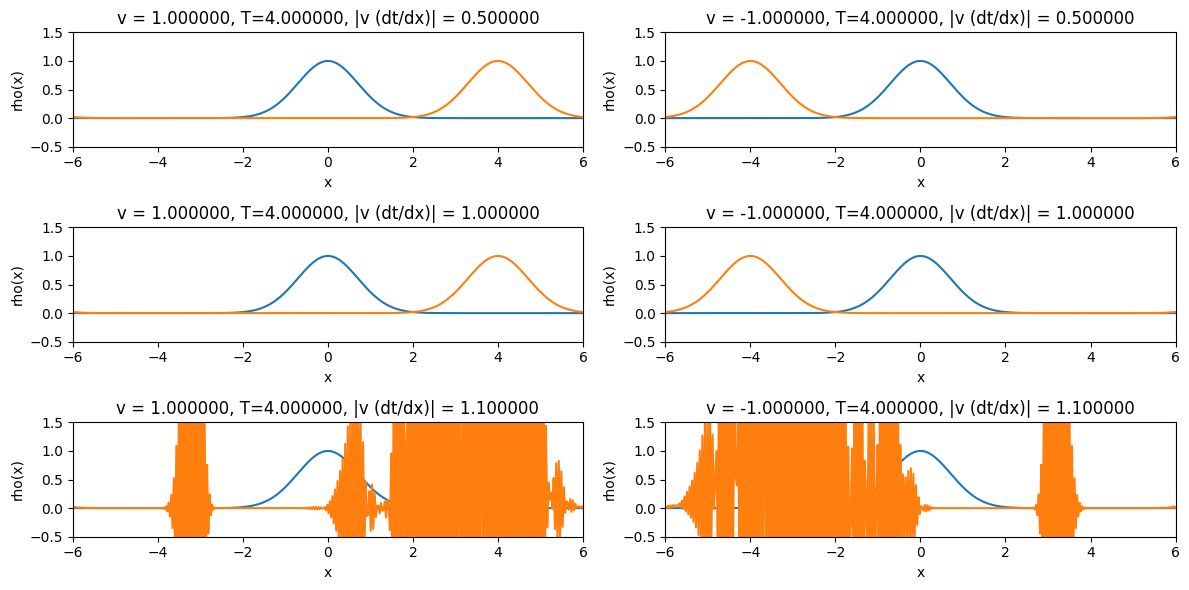

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_test_advection_lax_wendroff():
    '''
    Performs a test of the advection_lax_wendroff function
    '''
    N = 400

    x = np.linspace(-6.0, 6.0, N)
    dx = (x[-1]-x[0])/(N-1)
    #rho = (x < 1)*(x > -1)*1.0
    rho = np.exp(-x**2)

    fig, ax = plt.subplots(3,2, figsize=(12,6))

    vp = 1.0

    dts = [0.5*np.abs(dx/vp), 1.0*np.abs(dx/vp), 1.1*np.abs(dx/vp)]

    vs = [vp, -vp]

    T = 4

    for i, v in enumerate(vs) :
        for j, dt in enumerate(dts) :

            idx = i*len(dts) + j

            ax[j,i].plot(x,rho)
            nrho = np.copy(rho)
            for _ in range (int(T/dt)):
                nrho = advection_lax_wendroff(nrho, v, dx, dt)
            ax[j,i].plot(x,nrho)
            ax[j,i].set_xlabel("x")
            ax[j,i].set_ylabel("rho(x)")
            ax[j,i].set_title("v = {:f}, T={:f}, |v (dt/dx)| = {:f}".format(v, T, np.abs(v*(dt/dx))))
            ax[j,i].set_xlim(-6,6)
            ax[j,i].set_ylim(-0.5,1.5)

    plt.tight_layout()

do_test_advection_lax_wendroff()

### Exercise 4: use the MacCormack method to solve Burgers' equation

Consider Burgers' equation in 1D:

$\dfrac{\partial u}{\partial t} + \dfrac{\partial}{\partial x} \left({ \dfrac{1}{2} u^2 }\right) = 0$

Implement the [MacCormack scheme](https://en.wikipedia.org/wiki/MacCormack_method) to solve Burgers' equation by completing the code inside the `burgers_mac_cormack` function:

$u^p_i ~ = ~ u^{(n)}_i ~ - ~ \left({\dfrac{\Delta t}{\Delta x}}\right)  \left({ f\left({u^{(n)}_{i+1} }\right) - f\left({u^{(n)}_i }\right) }\right)$

$u^{n+1}_i ~ = ~ \dfrac{1}{2} \left({ u^{(n)}_i + u^{p}_i }\right) ~ - ~ \dfrac{1}{2} \left({\dfrac{\Delta t}{\Delta x}}\right) \left({ f\left({u^{p}_{i} }\right) - f\left({u^{p}_{i-1} }\right) }\right) $

where $f(u) = \dfrac{1}{2} u^2$

Note that Dirichlet boundary conditions are used, so you are not supposed to modify the first and the last element of the array `u`.

Run the code block `do_test_burgers_mac_cormack` to test your solution.

#### Ideas if you finish early:
Study the effect of a different timestep.
Change the initial conditions.

In [ ]:
def burgers_mac_cormack(u, dx, dt):
    """
    Computes one step of the MacCormack scheme applied to the 1D Burgers' equation:
    it receives u at time n and it returns u at time n+1.
    Dirichlet boundary conditions are applied using guard cells at u[0] and u[-1]

    Parameters
    ----------
    u : array of floats
        N-components vector of the values of u at time n
    dx : float
        spatial resolution
    dt : array of floats
        temporal resolution
    Returns
    -------
    new_u : array of floats
        u computed at timestep n+1
    """

    new_u = np.zeros(u.shape[0])
    up = np.zeros(u.shape[0])

    # Boundary conditions
    up[0] = u[0]
    up[-1] = u[-1]
    new_u[0] = u[0]
    new_u[-1] = u[-1]

    ### ADD YOUR CODE HERE ####
    f= 0.5*u**2
    up[1:-1] = u[1:-1] -dt/dx*(f[2:]-f[1:-1])
    fp=0.5*up**2
    new_u[1:-1] = (u[1:-1]+up[1:-1])/2 -dt/(2*dx)*(fp[1:-1]-fp[0:-2])

    ### ADD YOUR CODE HERE ####

    return new_u

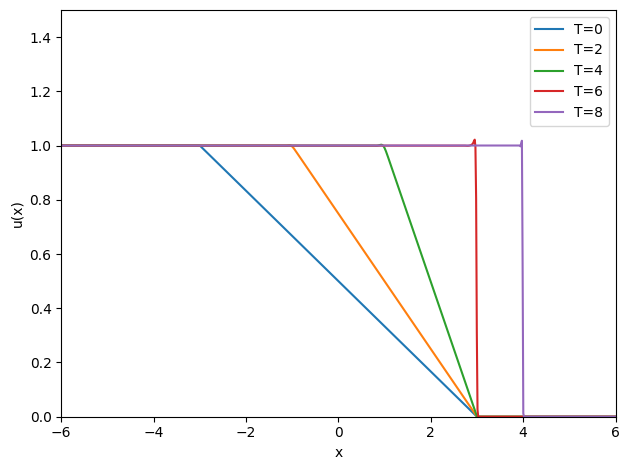

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def do_test_burgers_mac_cormack():
    '''
    Performs a test of the burgers_mac_cormack function
    '''
    N = 800
    x = np.linspace(-6.0, 6.0, N)
    dx = (x[-1]-x[0])/(N-1)

    u = -np.ones(N)
    u = (x < -3.0) + (x >= -3.0)*(x < 3.0)*(-(x+3)/6.0 + 1)

    fig, ax = plt.subplots(1)

    dt = 0.8*dx

    T = 8.0

    initial_u = np.copy(u)
    usave = []

    for i in range(4):
        for _ in range (int(T/dt/4)):
            u = burgers_mac_cormack(u, dx, dt)
        usave.append(u.copy())

    ax.plot(x,initial_u, label="T=0")
    ax.plot(x,usave[0], label="T=2")
    ax.plot(x,usave[1], label="T=4")
    ax.plot(x,usave[2], label="T=6")
    ax.plot(x,usave[3], label="T=8")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.set_xlim(-6,6)
    ax.set_ylim(0,1.5)

    plt.legend()

    plt.tight_layout()

do_test_burgers_mac_cormack()

### Exercise 5 (at home or if you have time): use the MacCormack method to solve the equation of a traffic flow model

Apply the MacCormack method to solve the equation of this traffic flow model:

$\dfrac{\partial \rho}{\partial t} + \dfrac{\partial}{\partial x} \left({ \rho v(\rho) }\right) = 0$

Where $\rho(x,t)$ describes the density of cars in a road and $v(\rho) = v_{max} (1 - \rho/\rho_{max})$ is an empirical model for the cars' velocity as a function of the cars density: cars move with a maximum velocity $v_{max}$ if the road is locally empty, but they slow down, potentially to zero, if there's traffic.